In [ ]:
!pip install -q huggingface_hub

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf

from pathlib import Path
from tensorflow import keras
from tensorflow.keras import layers
from huggingface_hub import create_repo, upload_folder

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Setting input parameters

In [ ]:
# Base dataset folder in Google Drive
DATASET_DIR = Path("/content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3")

# Metadata CSV created from your local preparation script
METADATA_CSV = Path("/content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_split_metadata.csv")

# Output folder on Drive
OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/baseline_cnn_rgb")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
df = pd.read_csv(METADATA_CSV)

print(df.head())
print(df["split"].value_counts())

           dish_id  total_carb split source_cafe
0  dish_1556575327      10.618  test       cafe1
1  dish_1557861216       0.000  test       cafe1
2  dish_1557862345       0.000  test       cafe1
3  dish_1557862696       3.850  test       cafe1
4  dish_1557862738       0.000  test       cafe1
split
train    2421
test      507
val       334
Name: count, dtype: int64


Building dataset

In [ ]:
# Build overhead RGB image path from dish_id
df["image_path"] = df["dish_id"].apply(
    lambda d: str(DATASET_DIR / d / "overhead" / "rgb.png")
)

# Check existence
df["image_exists"] = df["image_path"].apply(lambda p: Path(p).exists())

print("Missing images:", (~df["image_exists"]).sum())
df = df[df["image_exists"]].copy()

print(df["split"].value_counts())
print(df.head())

Missing images: 0
split
train    2421
test      507
val       334
Name: count, dtype: int64
           dish_id  total_carb split source_cafe  \
0  dish_1556575327      10.618  test       cafe1   
1  dish_1557861216       0.000  test       cafe1   
2  dish_1557862345       0.000  test       cafe1   
3  dish_1557862696       3.850  test       cafe1   
4  dish_1557862738       0.000  test       cafe1   

                                          image_path  image_exists  
0  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
1  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
2  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
3  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
4  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  


In [ ]:
train_df = df[df["split"] == "train"].copy()
val_df   = df[df["split"] == "val"].copy()
test_df  = df[df["split"] == "test"].copy()

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

Train: 2421
Val:   334
Test:  507


In [ ]:
IMG_HEIGHT = 640
IMG_WIDTH = 480
BATCH_SIZE = 8
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
def load_image_and_label(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)
    return image, label

In [ ]:
def make_dataset(dataframe, batch_size=8, shuffle=False):
    image_paths = dataframe["image_path"].values
    labels = dataframe["total_carb"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=42)

    ds = ds.map(load_image_and_label, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

In [ ]:
train_dataset = make_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True)
validation_dataset = make_dataset(val_df, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = make_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

Model architecture

In [ ]:
inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = layers.Rescaling(1.0 / 255)(inputs)

# Block 1
x = layers.SeparableConv2D(32, 3, padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D((2, 2))(x)

# Block 2
x = layers.SeparableConv2D(64, 3, padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D((2, 2))(x)

# Block 3
x = layers.SeparableConv2D(128, 3, padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D((2, 2))(x)

# Block 4
x = layers.SeparableConv2D(256, 3, padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D((2, 2))(x)

# Block 5
x = layers.SeparableConv2D(512, 3, padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D((2, 2))(x)

# Head
x = layers.Flatten()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="linear")(x)

model = keras.Model(inputs, outputs, name="baseline_cnn_rgb_carb_regression")
model.summary()

Model: "baseline_cnn_rgb_carb_regression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 640, 480, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 640, 480, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 640, 480, 32)   │           123 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 640, 480, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 640, 480, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 320, 240, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 320, 240, 64)   │         2,336 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 320, 240, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 320, 240, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 160, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 160, 120, 128)  │         8,768 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 160, 120, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 160, 120, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 80, 60, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 80, 60, 256)    │        33,920 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 80, 60, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 80, 60, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 40, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_4              │ (None, 40, 30, 512)    │       133,376 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 40, 30, 512)    │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 336,092 (1.28 MB)

 Trainable params: 334,108 (1.27 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ]
)

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(OUTPUT_DIR / "best_model.keras"),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

Training the model

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=100,
    callbacks=callbacks
)

Epoch 1/100
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 967.2099 - mae: 15.9441 - mse: 967.2099   
Epoch 1: val_loss improved from None to 542.39941, saving model to /content/drive/MyDrive/Speciale/Models/baseline_cnn_rgb/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/baseline_cnn_rgb/best_model.keras
303/303 ━━━━━━━━━━━━━━━━━━━━ 363s 1s/step - loss: 564.0624 - mae: 12.5778 - mse: 564.0624 - val_loss: 542.3994 - val_mae: 17.7739 - val_mse: 542.3994 - learning_rate: 0.0010
Epoch 2/100
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 571.4833 - mae: 11.3015 - mse: 571.4833
Epoch 2: val_loss improved from 542.39941 to 444.68735, saving model to /content/drive/MyDrive/Speciale/Models/baseline_cnn_rgb/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Speciale/Models/baseline_cnn_rgb/best_model.keras
303/303 ━━━━━━━━━━━━━━━━━━━━ 43s 142ms/step - loss: 494.9769 - mae: 11.4714 - mse: 494.9769 - val_loss: 444.6873 - val_

Plotting training and validation curves

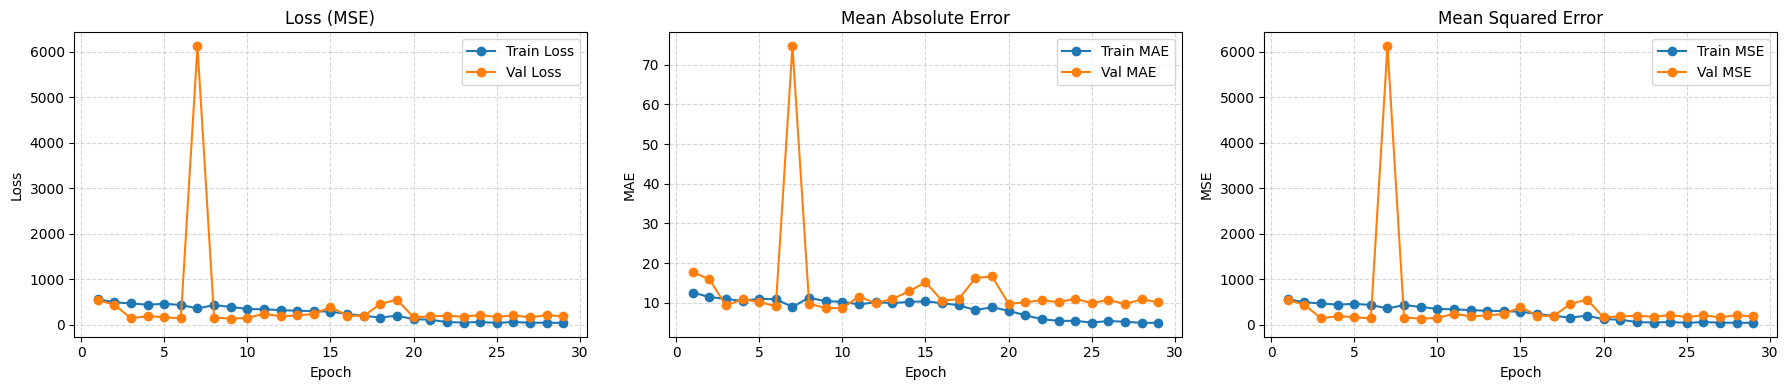

Best val_loss: 136.1670 at epoch 9
Val MAE at best epoch: 8.6600
Val MSE at best epoch: 136.1670


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_metrics(history):
    h = history.history
    epochs = np.arange(1, len(h["loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(epochs, h["loss"], marker="o", label="Train Loss")
    axes[0].plot(epochs, h["val_loss"], marker="o", label="Val Loss")
    axes[0].set_title("Loss (MSE)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.5)

    if "mae" in h and "val_mae" in h:
        axes[1].plot(epochs, h["mae"], marker="o", label="Train MAE")
        axes[1].plot(epochs, h["val_mae"], marker="o", label="Val MAE")
        axes[1].set_title("Mean Absolute Error")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("MAE")
        axes[1].legend()
        axes[1].grid(True, linestyle="--", alpha=0.5)

    if "mse" in h and "val_mse" in h:
        axes[2].plot(epochs, h["mse"], marker="o", label="Train MSE")
        axes[2].plot(epochs, h["val_mse"], marker="o", label="Val MSE")
        axes[2].set_title("Mean Squared Error")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("MSE")
        axes[2].legend()
        axes[2].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

    best = np.argmin(h["val_loss"])
    print(f"Best val_loss: {h['val_loss'][best]:.4f} at epoch {best + 1}")

    if "val_mae" in h:
        print(f"Val MAE at best epoch: {h['val_mae'][best]:.4f}")
    if "val_mse" in h:
        print(f"Val MSE at best epoch: {h['val_mse'][best]:.4f}")

plot_metrics(history)

Testing on the test set

In [ ]:
test_results = model.evaluate(test_dataset, return_dict=True)
print(test_results)

64/64 ━━━━━━━━━━━━━━━━━━━━ 212s 3s/step - loss: 218.0158 - mae: 10.7067 - mse: 218.0158
{'loss': 218.01583862304688, 'mae': 10.706745147705078, 'mse': 218.01583862304688}
